In [1]:
import sys
import os
from collections import namedtuple
from pathlib import Path
import json
import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io

from tqdm.notebook import tqdm

import torch
from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

import cgf

sys.path.append('..')
from lib.utils import *
from lib.logging import *

2025-12-15 12:12:14.767478: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-15 12:12:14.807890: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 12:12:15.545571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Setup

In [2]:
config = namedtuple('Config', 'data_path')(
    data_path=Path('..') / 'data' / 'denoise'
)

LOG = Logging()
RNG = np.random.default_rng()

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(notebook_fname)

s1_sparse_code_01.ipynb


# CGF Interface

In [3]:
def fit_bases(bases, patches, noise_var, β, σ, tol, max_iter):
    assert len(bases) == len(patches)
    L = len(bases)
    M = bases.shape[1]
    N = patches.shape[1]
    λ = 1 / noise_var
        
    bases_norm2 = np.sum(bases * bases, axis=0)
    # assert np.all(bases_norm2 > 0)
    coeffs_init = bases.T @ patches
    coeffs_init = (coeffs_init.T / bases_norm2).T

    # cgf module works with matrices in column-major layout (Fortran style), as such create output matrix with respect to this 
    coeffs = np.zeros((N, M), dtype=np.double)

    # cgf module works with matrices in column-major layout (Fortran style), as such prepare input matrices by transposing them
    req = lambda a: np.require(a, dtype=np.double, requirements=['C_CONTIGUOUS'])
    
    cgf.cgf(L, M, N, req(bases.T), req(patches.T), req(coeffs_init.T), req(coeffs), λ, β, σ, tol, max_iter)
    
    # turn back to row-major layout
    coeffs = coeffs.T 
    return coeffs

In [4]:
# bases = RNG.uniform(0, 1, (5, 2))
# patches = RNG.uniform(0, 1, (5, 3))
bases = np.array([[0.17896048, 0.69793457],
        [0.68849418, 0.40182392],
        [0.80887865, 0.58090589],
        [0.3946178 , 0.42024509],
        [0.38471327, 0.70067435]])

patches = np.array([[0.42034354, 0.59886737, 0.17633227],
        [0.33168091, 0.29535977, 0.70301482],
        [0.19661624, 0.19843791, 0.05798285],
        [0.30898698, 0.74006256, 0.66647841],
        [0.50870405, 0.29780236, 0.13198214]])

# patches = np.array([[0.42034354],
#         [0.33168091],
#         [0.19661624],
#         [0.30898698],
#         [0.50870405]])

bases, patches

(array([[0.17896048, 0.69793457],
        [0.68849418, 0.40182392],
        [0.80887865, 0.58090589],
        [0.3946178 , 0.42024509],
        [0.38471327, 0.70067435]]),
 array([[0.42034354, 0.59886737, 0.17633227],
        [0.33168091, 0.29535977, 0.70301482],
        [0.19661624, 0.19843791, 0.05798285],
        [0.30898698, 0.74006256, 0.66647841],
        [0.50870405, 0.29780236, 0.13198214]]))

In [5]:
fit_bases(bases, patches, 0.01, 2.2, 0.316, 0.01, 100)

array([[ 0.01871058, -0.0054778 ,  0.46587992],
       [ 0.57039434,  0.68044949,  0.09887369]])

In [6]:
# noise_var = 0.01
# β = 2.2
# σ = 0.316
# tol = .01
# max_iter = 100

# A = bases
# X = patches
# L = len(bases)
# M = bases.shape[1]
# N = patches.shape[1]

# Sinit = A.T @ X
# normA2 = np.sum(A * A, axis=0)
# Sinit = (Sinit.T / normA2).T
# λ = 1 / noise_var
# S = np.zeros((N, M))

# req = lambda a: np.require(a, dtype=np.double, requirements=['C_CONTIGUOUS'])

# cgf.cgf(L, M, N, req(A.T), req(X.T), req(Sinit.T), req(S), λ, β, σ, tol, max_iter)
# S.T

In [7]:
# m = np.array([[1,2,3], [4,5,6]], dtype=np.double).T
# m_p = np.require(m, dtype=np.double, requirements=['C_CONTIGUOUS'])
# cgf.cgf_test(m.shape[0], m.shape[1], m_p, 12.0)

In [8]:
# m = np.array([[1,2,3], [4,5,6]], dtype=np.double).T
# m_p = np.require(m, dtype=np.double, requirements=['C_CONTIGUOUS'])
# cgf.cgf_test2(m.shape[0], m.shape[1], m_p)

# Images

In [41]:
# fname, mat_name = 'IMAGES.mat', 'IMAGES'
fname, mat_name = 'IMAGES_RAW.mat', 'IMAGESr'
mat = scipy.io.loadmat(config.data_path / fname)
IMAGES = mat[mat_name]
IMAGES = np.moveaxis(IMAGES, [2], [0])
IMAGE_STDS = IMAGES.reshape(IMAGES.shape[0], -1).std(axis=1)

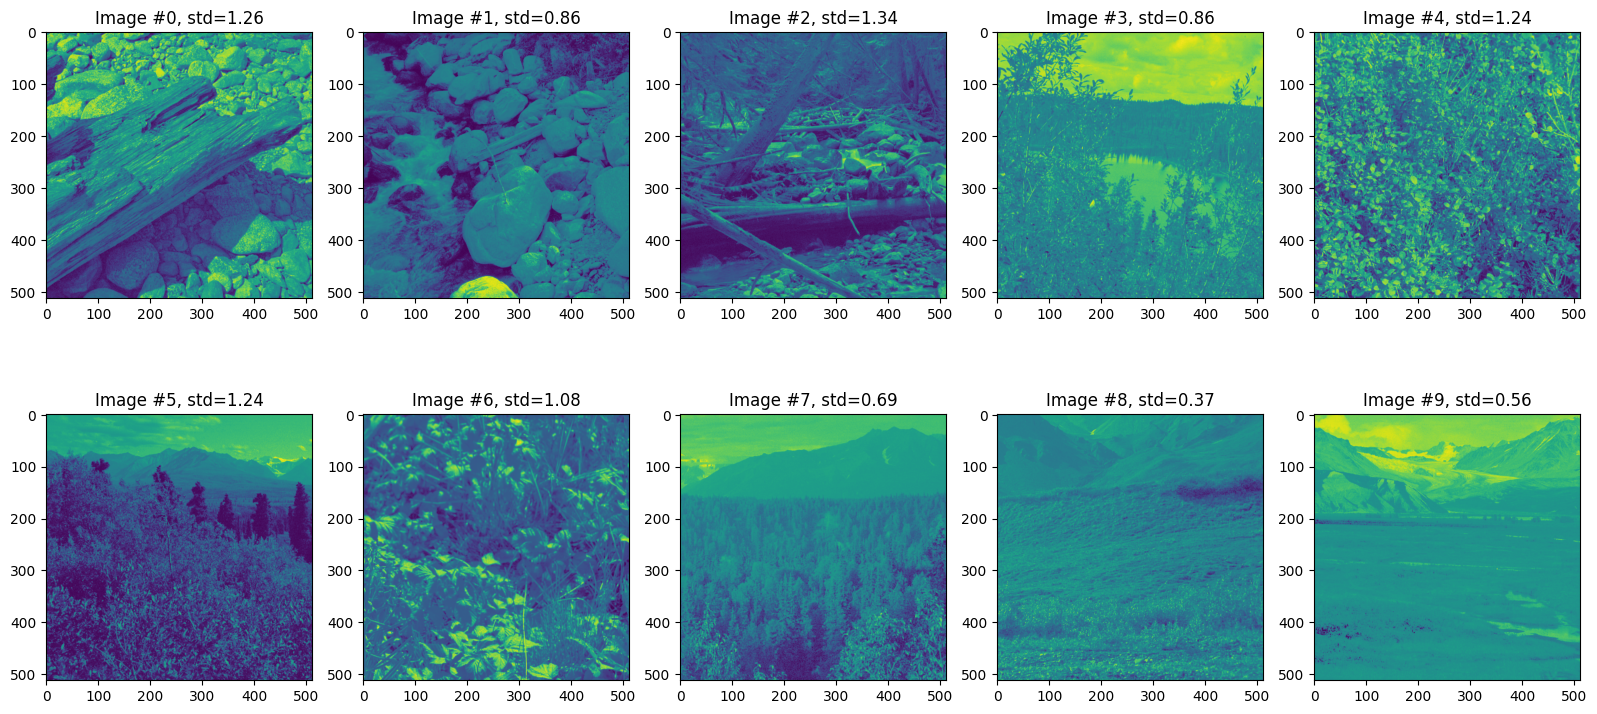

In [42]:
show_count = 10
fig, axes = plt.subplots(show_count // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for i, ax in zip(np.arange(len(IMAGES))[:show_count], axes.ravel()):
    ax.set_title(f'Image #{i}, std={IMAGE_STDS[i]:.2f}')
    ax.imshow(IMAGES[i]);

plt.tight_layout();

# Patching

In [11]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(patch_size, image_ind=None, with_std=True):
    blind_area = 4
    trials = 1000
    image_ind = RNG.choice(IMAGES.shape[0]) if image_ind is None else image_ind
    image = IMAGES[image_ind]
    image_std_thres = IMAGE_STDS[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + RNG.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + RNG.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + HP_PATCH_SIZE, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

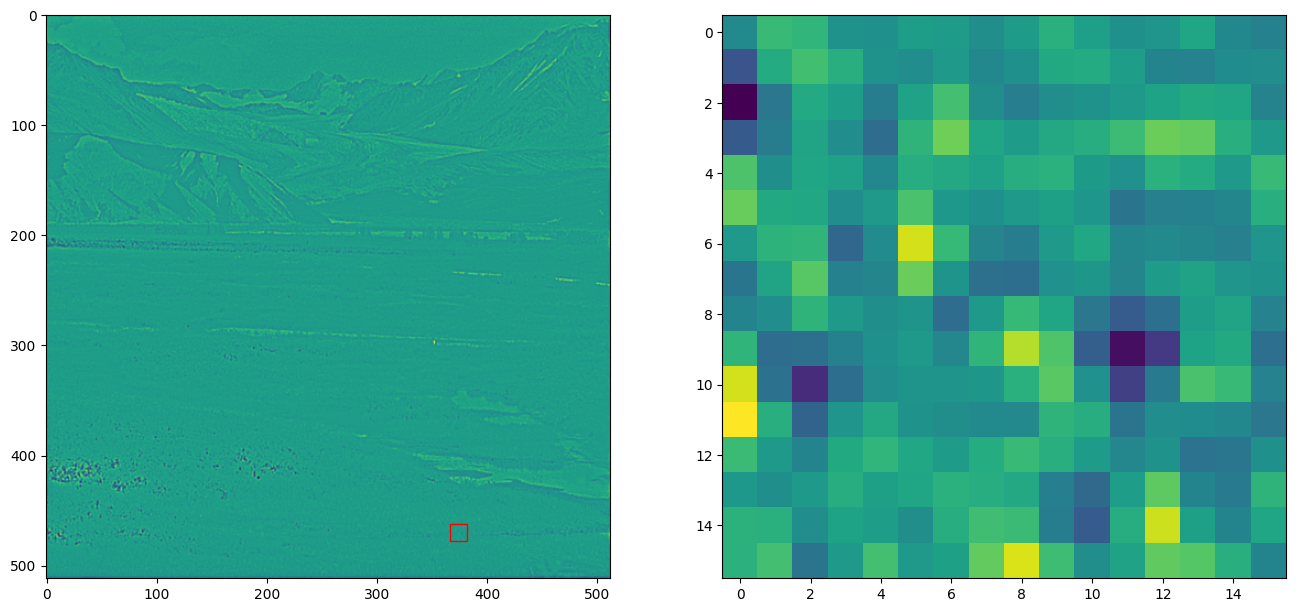

In [25]:
patch, image_ind, i_off, j_off = extract_image_patch(16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(IMAGES[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Training

**Config for "Olshausen et al. Emergence of simple-cell receptive field properties by learning a sparse code for natural images"**

1) Results from training a system of 192 basis functions on 16 x 16-pixel image patches extracted form natural scenes. The scenes were ten 512 x 512 images of natural surroundings in the American northwest, preprocessed by filtering with the zero-phase whitenin low pass filter ... Whitening counteracts the fact that the mean-square error (or m.s.e.) preferentially weights low frequencies for natural scenes, whereas the attenuation at high spatial-frequencies eliminates artefacts of rectangular sampling.
2) The A were computed by the conjugate gradient method, halting when the change in E was less than 1%. The ϕ_i were initialized to random values and were updated every 100 image presentations. The vector length (gain) of each basis function, ϕ_i, was adapted over time so as to maintain equal variance on each coefficient. A stable solution was anived at after 4,000 updates (400,000 image presentations). The parameter λ, was set that λ/σ = 0.14, with σ^2 set to the variance of the images. The form of the sparseness cost function was S(x) = log(1 + x^2). 


**Config for "Olshausen et al. Sparse Coding with an Overcomplete Basis Set: A Strategy Employed by V1"**

1) Training data were obtained by extracting 12x12 image patches at random from the preprocessed images, skipping over any patch within four pixels of the border of the image. Also, to speed up training, any image patch with less than 10% of the average image variance was discarded, as these patches have such low variance that they contribute little to establishing a gradient
2) A set of 144 basis functions was initialized to random values and was updated according to equations (17, 18) based on averages computed over every 100 image presentations. The learning rate parameter η was gradually lowered during learning, with an initial setting of 5.0 for the first 600 iterations, then 2.5 for the second 600 iterations, and finally 1.0 for the remainder. The rate
parameter for the gain adjustment, α, was set to 0.01 and the target level for the output variance, σ_goal^2, was set to the variance of the image pixels, σ_I^2.
The value of the parameter λ was set relative to σ_I so that λ/σ_I = 0.1. The form of the sparseness cost function was S(x) = log(1 + x^2). 

In [43]:
# Ca. config for "Olshausen et al. Emergence of simple-cell receptive field properties by learning a sparse code for natural images"
# HP_PATCH_SIZE = 16
# HP_BASE_FUNCS_COUNT = 192
# HP_TRIALS_COUNT = 4_000

# HP_EXTR_PATCH_WITH_STD = False
# HP_NOISE_VAR = 0.01   # noise variance (sigma_N^2 in Vision Research paper, eq. 6)
# HP_BETA = 2.2         # steepness of prior (beta in Vision Research paper, eq. 8)
# HP_SIGMA = 0.316      # scaling parameter for prior (sigma in Nature paper)
# HP_TOL = 0.01         # tolerance for conjugate gradient routine
# HP_MAX_ITER = 100
# HP_ETA_SCHEDULE = np.full(HP_TRIALS_COUNT, 1) # learning rate (eta in Nature/Vision Research paper)
# HP_COEFFS_VAR_GOAL = 0.1
# HP_VAR_ETA = 0.001    # average rate for S_var
# HP_ALPHA = 0.02       # gain adaptation rate

# # Ca. config for "Olshausen et al. Sparse Coding with an Overcomplete Basis Set: A Strategy Employed by V1"
HP_PATCH_SIZE = 12
HP_BASE_FUNCS_COUNT = 144
HP_TRIALS_COUNT = 2_000

HP_EXTR_PATCH_WITH_STD = True
HP_NOISE_VAR = 0.01   # noise variance (sigma_N^2 in Vision Research paper, eq. 6)
HP_BETA = 2.2         # steepness of prior (beta in Vision Research paper, eq. 8)
HP_SIGMA = 0.316      # scaling parameter for prior (sigma in Nature paper)
HP_TOL = 0.01         # tolerance for conjugate gradient routine
HP_MAX_ITER = 100
HP_ETA_SCHEDULE = np.full(HP_TRIALS_COUNT, 1) # learning rate (eta in Nature/Vision Research paper)
HP_ETA_SCHEDULE[:600] = 5
HP_ETA_SCHEDULE[600:1200] = 2.5
HP_COEFFS_VAR_GOAL = 0.1
HP_VAR_ETA = 0.001    # average rate for S_var
HP_ALPHA = 0.02       # gain adaptation rate

# ==============
HP_BATCH_SIZE = 100
HP_BASE_FUNC_DIMS = HP_PATCH_SIZE ** 2

In [44]:
metrics_dir = os.path.join('run', datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S'))
metrics_writer = SummaryWriter(log_dir=metrics_dir)

# each base is a COLUMN vector!
bases = RNG.uniform(0, 1, (HP_BASE_FUNC_DIMS, HP_BASE_FUNCS_COUNT)) - 0.5
bases_norm = np.linalg.norm(bases, axis=0)
bases = bases / bases_norm
 
coeffs_var = HP_COEFFS_VAR_GOAL * np.ones(HP_BASE_FUNCS_COUNT) # actual variance of the coefficients, aka a_i variance
gain = np.linalg.norm(bases, axis=0)

for trial_no in tqdm(range(HP_TRIALS_COUNT)):
    image_ind = RNG.choice(len(IMAGES))
    patches = []

    for _ in range(HP_BATCH_SIZE):
        patch = extract_image_patch(HP_PATCH_SIZE, image_ind, with_std=HP_EXTR_PATCH_WITH_STD)
        patches.append(patch.patch)

    # each patch is a COLUMN vector!
    patches = np.array(patches)
    patches = patches.reshape(len(patches), -1) # e.g. (100, 12, 12) -> (100, 144)
    patches = patches.T

    # calculate coefficients (referred to a_i in article) for these patches: row - base func, col - image patch
    coeffs = fit_bases(bases, patches, HP_NOISE_VAR, HP_BETA, HP_SIGMA, HP_TOL, HP_MAX_ITER)
    # assert np.all(np.any(coeffs, axis=0))

    # calculate residual error, shape the same as patches
    reconstr_patches = bases @ coeffs
    residual_error = patches - reconstr_patches

    metrics_writer.add_scalar('res_err_sum', residual_error.sum(), trial_no)
    metrics_writer.add_scalar('res_err_mean', residual_error.sum(axis=0).mean(), trial_no)

    # update bases
    # This yields the learning rule: Δϕ_i = η<a_i*r> (в статье есть опечатка в формуле 17 - пропущена закрывающая скобка перед знаком "равно"),
    # where η is the learning rate. In terms of the network implementation shown in Fig. 5, the ϕ_i are updated by simple Hebbian learning between 
    # the outputs computed for each image, a_i, and the resulting residual image, r. Note: <...> - means averaging.
    # Т.к. a_i можно рассматривать как реакцию нейрона (хитрожопая реакция, нелинейная), 
    # то правило обучения Хебба тут прям один в один (w_i(n+1) = w_i(n) + η * y(n) * x_i(n)) с единственным замечанием, 
    # что x_i(n) есть не исходный сигнал (картинка), а остаточная картинка
    delta_bases = np.zeros_like(bases)

    for i in range(HP_BATCH_SIZE):
        # outer product of two vectors: 1) redisual_error column vector for patch, 2) coeffs row vector for patch
        delta_bases_for_patch = residual_error[:,i][:,np.newaxis] @ coeffs[:,i][np.newaxis,:]
        delta_bases = delta_bases + delta_bases_for_patch

    delta_bases /= HP_BATCH_SIZE

    η = HP_ETA_SCHEDULE[trial_no]
    bases = bases + η * delta_bases
    
    # normalize bases in a classical way to prevent them from growing infinitely large
    bases_norm = np.linalg.norm(bases, axis=0)
    bases /= bases_norm

    # adjust bases to match desired output variance for each a_i
    # As mentioned above, though, doing this alone will result in the ϕ_i growing without bound, 
    # and so to prevent this from happening the L2 norm of each basis function, l_i^2 = Σϕ_i^2, 
    # is separately adapted so that the output variance of each a_i is held at an appropriate level
    # 1) В оригинальном sparsenet эта операция была объединена с нормализацией, т.е. bases *= gain / bases_norm
    # Здесь для лучшего понимания логика была разделена явно (нормализация выше, корректировка здесь).
    # 2) Похоже здесь предполагается, что среднее значение каждого из a_i равно 0, иначе не объяснить,
    # почему дисперсия считается просто как квадрат
    # 3) Здесь по ходу решается задача a-la backprop. У нас есть наблюдаемая дисперсия a_i, есть желаемая дисперсия a_i, 
    # что надо сделать, чтобы наблюдаемая дисперсия была близко в желаемой? Повлиять на дисперсию
    # можно только через ϕ_i, т.к. a_i есть по-сути реакция нейрона (вычисляемая хрень), поэтому ничего не остаётся как делать
    # вот такой вот странноватый backward update (пятимся назад)
    for i in range(HP_BATCH_SIZE):
        # update coeffs_var (aka a_i variance) via recursive average filter idiom
        coeffs_var = (1 - HP_VAR_ETA) * coeffs_var + HP_VAR_ETA * (coeffs[:,i]**2)

    # С такой формулой gain будет потихоньку расти для coeffs_var > HP_COEFFS_VAR_GOAL и уменьшаться
    # наоборот. Значит ϕ_i, у которых var(a_i) > HP_COEFFS_VAR_GOAL  будет получать небольшую прибавку и наоборот (см. график ниже)
    # В sparsenet-tcl такая же логика только без деления: gain[i] += 0.1*(a_var[i]-VAR_GOAL), и при этом 
    # там в контексте overlap ещё это рассматривается
    gain *= (coeffs_var / HP_COEFFS_VAR_GOAL) ** HP_ALPHA
    bases *= gain


  0%|          | 0/2000 [00:00<?, ?it/s]

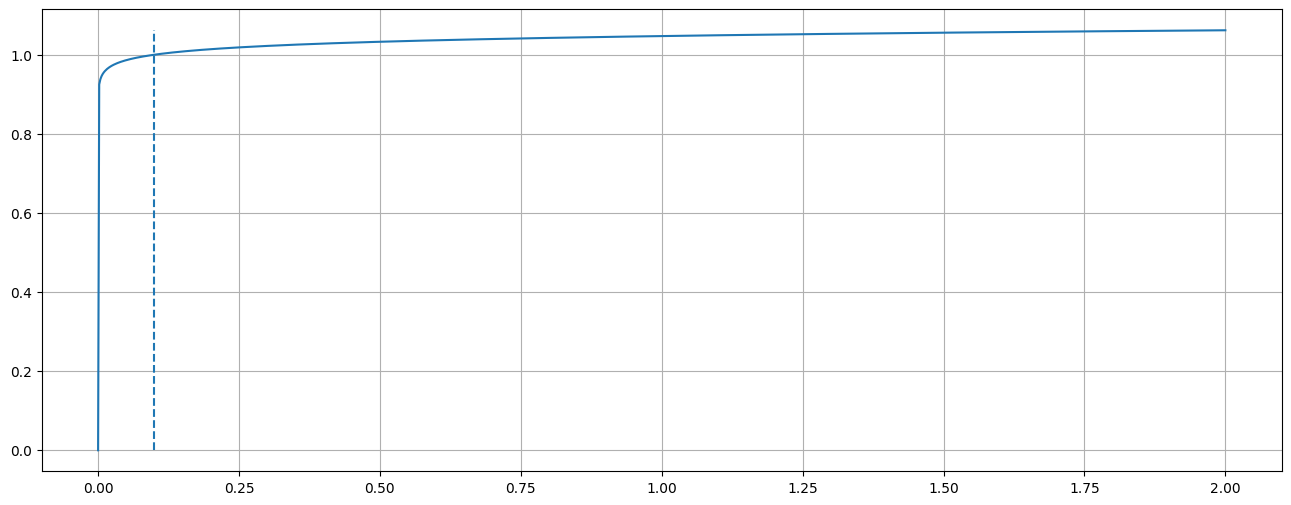

In [45]:
plt.figure(figsize=(16, 6))
x = np.linspace(0, 2, 1000)
y = np.pow(x/HP_COEFFS_VAR_GOAL, HP_ALPHA)
plt.plot(x, y)
plt.vlines(HP_COEFFS_VAR_GOAL, 0, np.max(y), linestyles='dashed')
plt.grid()

<BarContainer object of 144 artists>

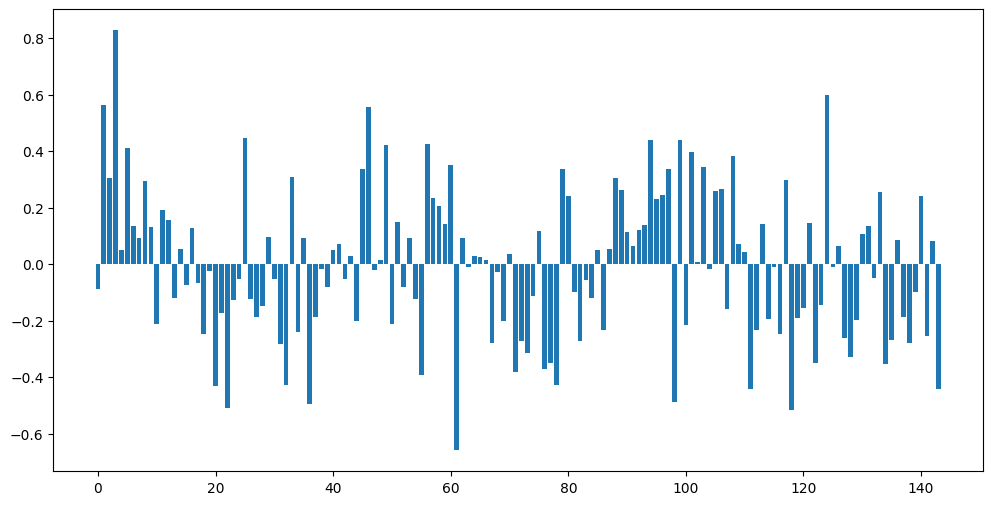

In [46]:
plt.figure(figsize=(12, 6))
plt.bar(np.arange(len(coeffs)), coeffs[:,0])

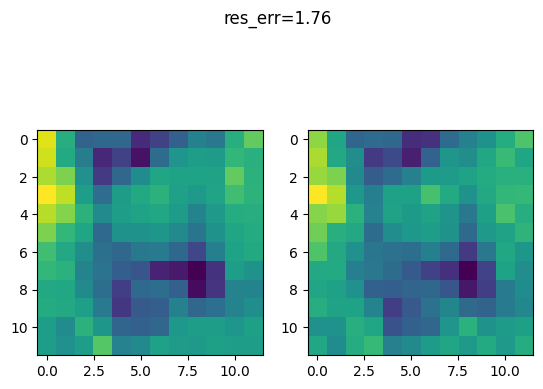

In [56]:
i = RNG.choice(patches.shape[1])
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(vec_to_square_matrix(patches[:,i]))
ax2.imshow(vec_to_square_matrix(reconstr_patches[:,i]))
plt.suptitle(f'res_err={(patches[:,i] - reconstr_patches[:,i]).sum():.2f}');

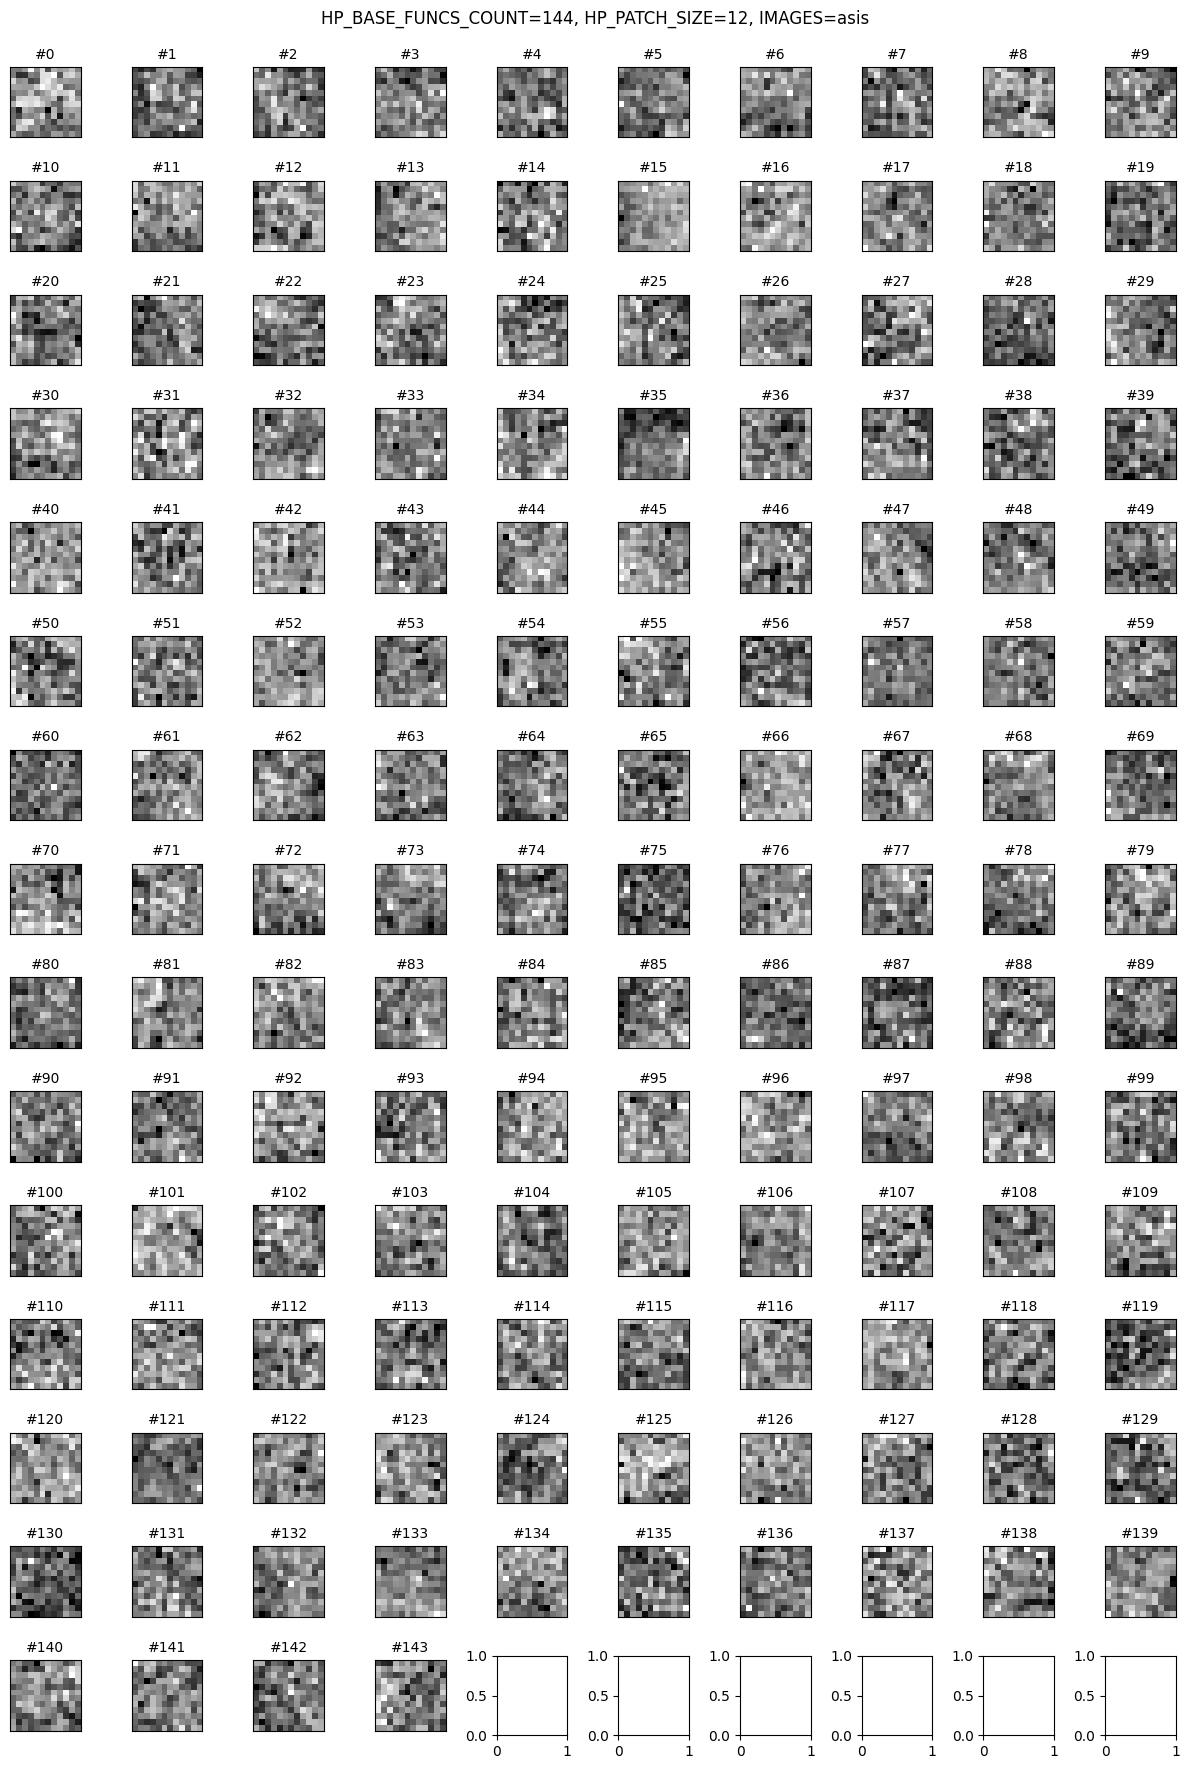

In [58]:
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP_BASE_FUNCS_COUNT / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)

for i, (base, ax) in enumerate(zip(bases.T, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(base), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'HP_BASE_FUNCS_COUNT={HP_BASE_FUNCS_COUNT}, HP_PATCH_SIZE={HP_PATCH_SIZE}, IMAGES=asis\n')
plt.tight_layout()

# Results

## 144/12/whitened
![](./img/144-12-whitened.png)

## 144/12/asis

![](./img/144-12-asis.png)

## 192/16/whitened
![](./img/192-16-whitened.png)